Importing:

In [1]:
from ml_spbu.homework_2.KNNClassifier.knn_classifier import KNNClassifier
from ml_spbu.homework_2.metrics.distance import euclidean_distance, manhattan_distance, minkowski_distance
from ml_spbu.homework_2.metrics.classification import accuracy_score, f1_score
from ml_spbu.homework_2.normalizers import MinMaxScaler, RobustScaler, StandardScaler
from ml_spbu.homework_2.train_test_split import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

Loading dataset into dataframe and check:

In [2]:
df = pd.read_csv('cancer.csv')
df.describe()

,1,2,3,4,5,6,7,8,9,10,...,21,22,23,24,25,26,27,28,29,30
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Change labels to 0 and 1:

In [3]:
df.loc[df["label"] == "B", "label"] = 0
df.loc[df["label"] == "M", "label"] = 1
df["label"]

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: label, Length: 569, dtype: object

Let's check the balance of the classes:

In [4]:
df["label"].value_counts()

label
0    357
1    212
Name: count, dtype: int64

So our KNN accuracy must be greater than 0.62

Lets convert it into Points:

In [5]:
y = list(df["label"])

def row_to_tuple_of_numbers(row):
  numbers = []
  for i, value in enumerate(row):
      if i == 0:
          continue
      numbers.append(value)
  return tuple(numbers)

X = df.apply(row_to_tuple_of_numbers, axis=1).tolist()
X[0]

(17.99,
 10.38,
 122.8,
 1001.0,
 0.1184,
 0.2776,
 0.3001,
 0.1471,
 0.2419,
 0.07871,
 1.095,
 0.9053,
 8.589,
 153.4,
 0.006399,
 0.04904,
 0.05373,
 0.01587,
 0.03003,
 0.006193,
 25.38,
 17.33,
 184.6,
 2019.0,
 0.1622,
 0.6656,
 0.7119,
 0.2654,
 0.4601,
 0.1189)

Let's use scaler:

# MinMaxScaler

In [6]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

(0.5210374366983767,
 0.022658099425092997,
 0.5459885287817012,
 0.3637327677624602,
 0.5937528211609642,
 0.7920372983252562,
 0.7031396438612932,
 0.7311133200795229,
 0.6863636363636364,
 0.6055181128896379,
 0.35614702154626104,
 0.12046941301272983,
 0.3690335956273854,
 0.2738112581668217,
 0.15929564537512322,
 0.3513984438369334,
 0.13568181818181818,
 0.30062511839363515,
 0.3116451848933416,
 0.1830424388154167,
 0.6207755247242974,
 0.1415245202558635,
 0.6683101748095025,
 0.4506979944946913,
 0.6011358383411478,
 0.6192915563058473,
 0.5686102236421725,
 0.9120274914089348,
 0.5984624482554701,
 0.4188639643185098)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

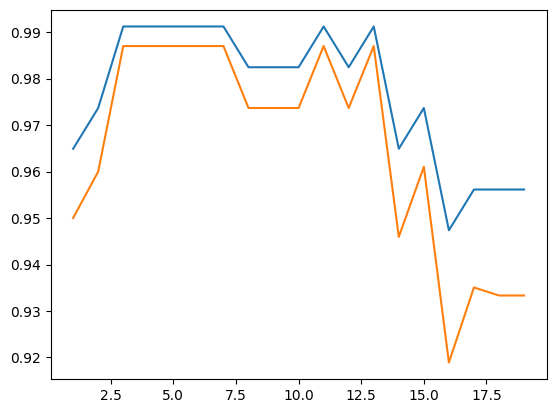

In [8]:
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

# StandardScaler

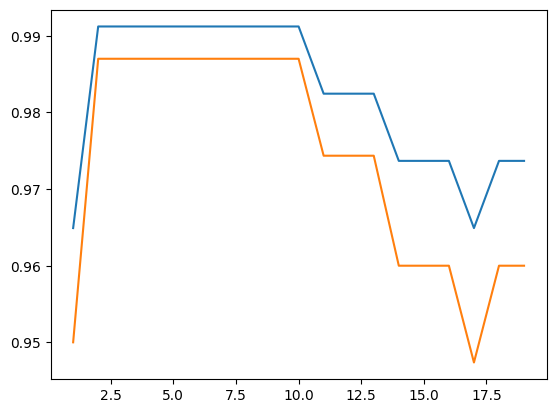

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

# RobustScaler

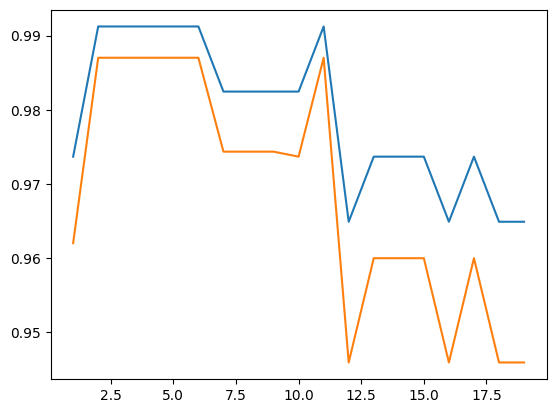

In [10]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()